# Robustness visualizations (Sets 1–3)

This notebook rebuilds the OFAT-sweep panel figures for the three
robustness appendices from the cached per-run JSONs in
`robustness/task{1,2,3}/`. Every figure
cell exposes a `style` dict at the top so you can edit colors, markers,
axis labels, legend placement, panel ordering, etc. without touching the
aggregators in `robustness/robustness_task{1,2,3}_analyze.py`.

Assumes the notebook lives at the repo root alongside `robustness/` and
`figs/`. If you move it, update `REPO` in the setup cell.


## Setup


In [ ]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Resolve paths — allow the notebook to be run from the repo root or a subdir.
REPO = Path.cwd()
if not (REPO / "robustness").exists():
    for parent in REPO.parents:
        if (parent / "robustness").exists():
            REPO = parent
            break

ROBUST_DIR = REPO / "robustness"
FIG_DIR = REPO / "figs" / "robustness"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROBUST_DIR))

import robustness_task1_analyze as t1
import robustness_task2_analyze as t2
import robustness_task3_analyze as t3
for _m in (t1, t2, t3):
    importlib.reload(_m)

print(f"REPO       = {REPO}")
print(f"ROBUST_DIR = {ROBUST_DIR}")
print(f"FIG_DIR    = {FIG_DIR}")
print()
print(f"Task 1: {len(t1.CONFIG_META):>2} configs, sensitive = {t1.TREATMENTS_SENS}")
print(f"Task 2: {len(t2.CONFIG_META):>2} configs, sensitive = {t2.SENSITIVE}")
print(f"Task 3: {len(t3.CONFIG_META):>2} configs, sensitive = {t3.SENSITIVE}")


## Load aggregates from cached JSONs

Each row is one `(config, treatment)` cell, aggregated across the five
seeds `[11, 13, 17, 19, 23]`. `mean_U` is the per-run mean trip utility
averaged over seeds (±SD). `pct_harmed` / `orc` are paired against the
seed-matched No-RS run at the baseline configuration.


In [37]:
# --- Task 1 (TCE / uncertainty knobs) ------------------------------------
T1_OUT = ROBUST_DIR / "task1"
baseline_no_rs = {}
for s in t1.SEEDS:
    run = t1._load_run(T1_OUT, "baseline", "no_rs", s)
    baseline_no_rs[s] = {int(k): float(v)
                         for k, v in run["agent_utilities"].items()}

t1_rows = []
for cname, label, group, _ in t1.CONFIG_META:
    for tr in t1.TREATMENTS_SENS:
        agg = t1._aggregate_treatment(T1_OUT, cname, tr, baseline_no_rs)
        t1_rows.append({
            "knob": group, "config": cname, "level_label": label,
            "treatment": tr, "treatment_label": t1.TREATMENT_LABELS[tr],
            **agg,
        })
t1_invariant = {tr: t1._aggregate_treatment(T1_OUT, "baseline", tr, baseline_no_rs)
                for tr in t1.TREATMENTS_INV}

# --- Task 2 (personalization / feedback-learning knobs) ------------------
T2_OUT = ROBUST_DIR / "task2"
t2_rows = t2.build_rows(T2_OUT)
t2_invariant = t2.build_invariant_summary(T2_OUT)

# --- Task 3 (RS-stack / catalog knobs) -----------------------------------
T3_OUT = ROBUST_DIR / "task3"
t3_rows = t3.build_rows(T3_OUT)
t3_invariant = t3.build_invariant_summary(T3_OUT)

print(f"Task 1: {len(t1_rows):>3} rows   invariants: {list(t1_invariant)}")
print(f"Task 2: {len(t2_rows):>3} rows   invariants: {list(t2_invariant)}")
print(f"Task 3: {len(t3_rows):>3} rows   invariants: {list(t3_invariant)}")

df1 = pd.DataFrame(t1_rows)
df2 = pd.DataFrame(t2_rows)
df3 = pd.DataFrame(t3_rows)
df1.head()

# Change treatment label for RM to just be "RM" instead of "RM (ε = 0.27)" since the ε value is not relevant to the visualizations and just adds clutter.
t1.TREATMENT_LABELS["rm"] = "RM"
t2.TREATMENT_LABELS["rm"] = "RM"
t3.TREATMENT_LABELS["rm"] = "RM"


Task 1:  26 rows   invariants: ['no_rs', 'standard', 'oracle']
Task 2:  39 rows   invariants: ['no_rs', 'standard', 'oracle', 'pup_03', 'rm']
Task 3:  39 rows   invariants: ['no_rs', 'oracle', 'standard', 'pup_03', 'rm']


## Set 1 — TCE / uncertainty knobs

2×3 panel. Each panel shows mean per-trip utility (±1 seed-SD) for
PUP-0.3 and RM across three levels of a TCE / uncertainty knob
(lower, baseline, upper). Horizontal references: No RS, Standard RS,
Oracle — all taken from the baseline-config run.

Edit the `style` dict below to restyle.


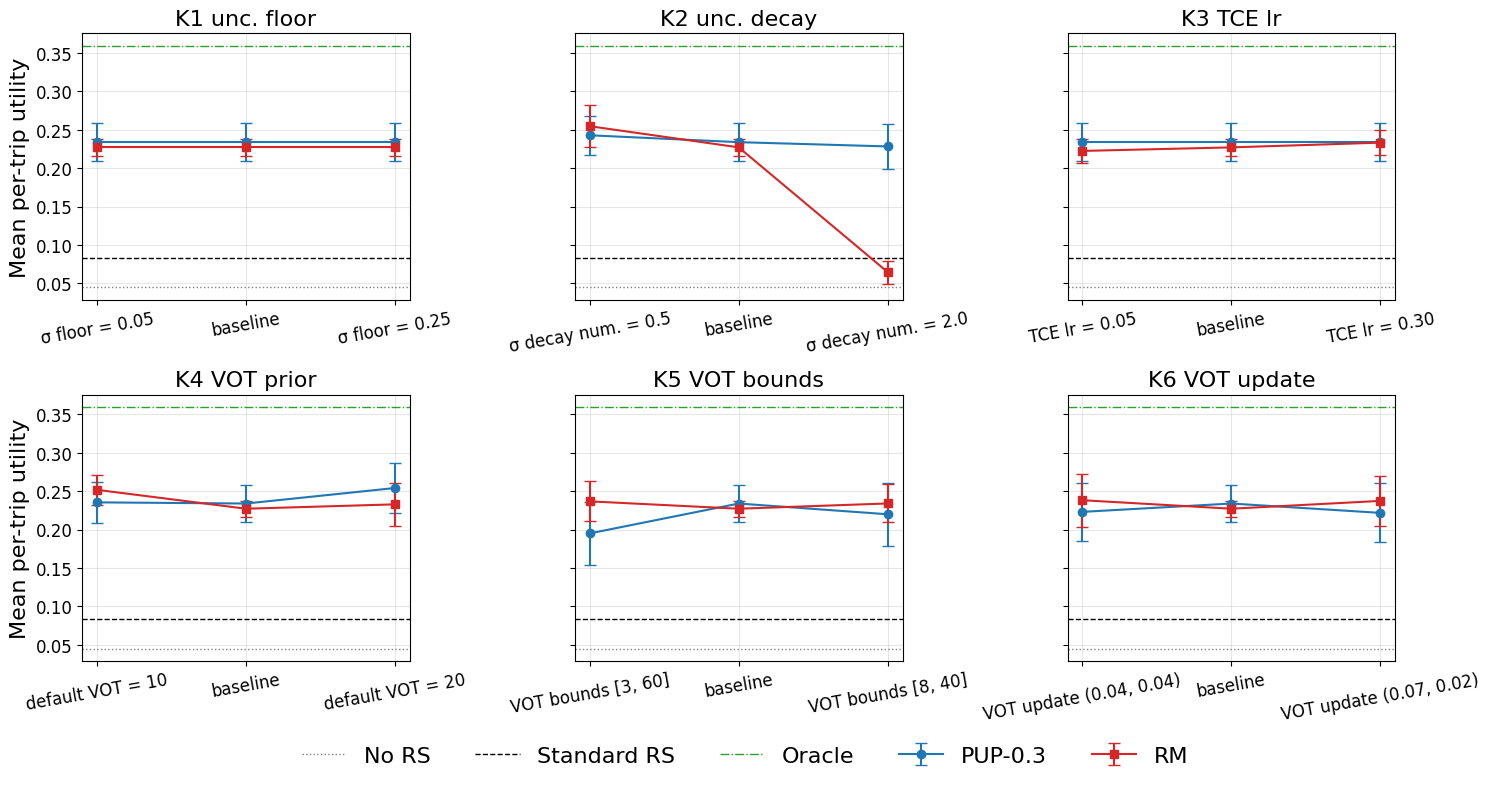

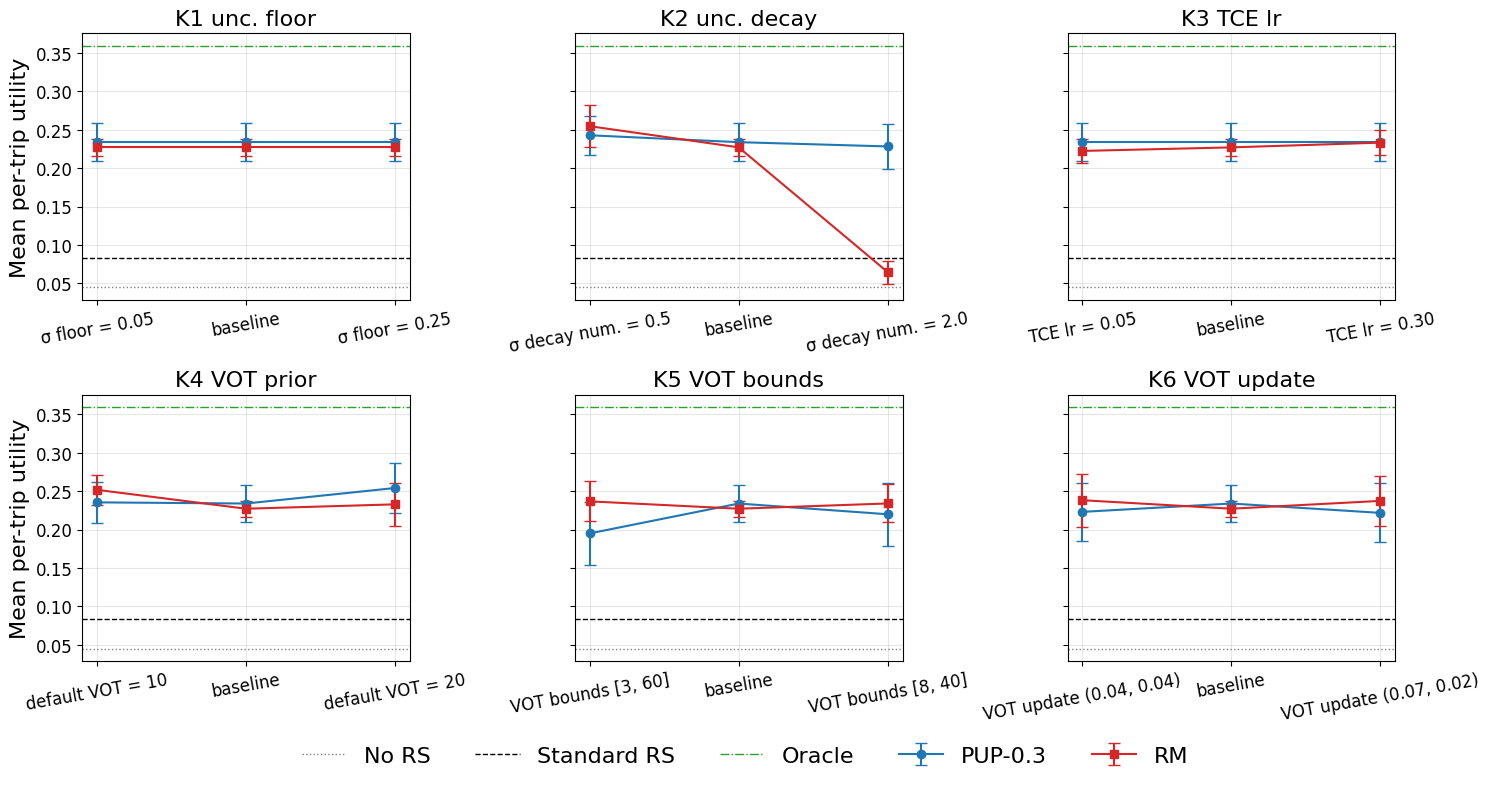

In [38]:
style = {
    "figsize": (15, 8),
    "sharey": True,
    "suptitle": "Task 1: OFAT sensitivity — TCE / uncertainty knobs",
    "suptitle_fs": 14,
    "suptitle_y": 0.995,
    "panel_title_fs": 16,
    "y_label": "Mean per-trip utility",
    "colors":  {"pup_03": "#1f77b4", "rm": "#d62728"},
    "markers": {"pup_03": "o",        "rm": "s"},
    "linestyle": "-",
    "capsize": 4,
    "marker_size": 6,
    "line_width": 1.5,
    "ref_styles": {
        "no_rs":    dict(color="gray",    linestyle=":",  lw=1.0, label="No RS"),
        "standard": dict(color="black",   linestyle="--", lw=1.0, label="Standard RS"),
        "oracle":   dict(color="#2ca02c", linestyle="-.", lw=1.0, label="Oracle"),
    },
    "xtick_fs": 12,
    "xtick_rot": 10,
    "grid_alpha": 0.3,
    "legend_ncol": 5,
    "legend_y": -0.02,
    "legend_fs": 16,
    "ytick_fs": 12,
}

knob_order = ["K1 unc. floor", "K2 unc. decay", "K3 TCE lr",
              "K4 VOT prior",  "K5 VOT bounds", "K6 VOT update"]
lo_suffixes = ("_lo", "_sym", "_wide")
hi_suffixes = ("_hi", "_steep", "_narrow")

ref_U = {tr: t1_invariant[tr]["mean_U_mean"] for tr in t1.TREATMENTS_INV}

fig1, axes1 = plt.subplots(2, 3, figsize=style["figsize"], sharey=style["sharey"])
for ax, knob in zip(axes1.ravel(), knob_order):
    lo_rows = df1[(df1["knob"] == knob) & df1["config"].str.endswith(lo_suffixes)]
    hi_rows = df1[(df1["knob"] == knob) & df1["config"].str.endswith(hi_suffixes)]
    x = np.arange(3)
    for tr in t1.TREATMENTS_SENS:
        lo = lo_rows[lo_rows["treatment"] == tr].iloc[0]
        hi = hi_rows[hi_rows["treatment"] == tr].iloc[0]
        bl = df1[(df1["config"] == "baseline") & (df1["treatment"] == tr)].iloc[0]
        means = [lo["mean_U_mean"], bl["mean_U_mean"], hi["mean_U_mean"]]
        sds   = [lo["mean_U_sd"],   bl["mean_U_sd"],   hi["mean_U_sd"]]
        ax.errorbar(
            x, means, yerr=sds,
            marker=style["markers"][tr],
            color=style["colors"][tr],
            linestyle=style["linestyle"],
            capsize=style["capsize"],
            lw=style["line_width"],
            ms=style["marker_size"],
            label=t1.TREATMENT_LABELS[tr],
        )
        if tr == t1.TREATMENTS_SENS[0]:
            ax.set_xticks(x)
            ax.set_xticklabels([lo["level_label"], "baseline", hi["level_label"]],
                               fontsize=style["xtick_fs"], rotation=style["xtick_rot"])
            ax.tick_params(axis='y', labelsize=style["ytick_fs"])
    for tr_ref, kw in style["ref_styles"].items():
        ax.axhline(ref_U[tr_ref], **kw)
    ax.set_title(knob, fontsize=style["panel_title_fs"])
    ax.grid(alpha=style["grid_alpha"])

axes1[0, 0].set_ylabel(style["y_label"], fontsize=style["panel_title_fs"])
axes1[1, 0].set_ylabel(style["y_label"], fontsize=style["panel_title_fs"])
handles, labels = axes1[0, 0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="lower center", ncol=style["legend_ncol"],
            frameon=False, bbox_to_anchor=(0.5, style["legend_y"]),
            fontsize=style["legend_fs"])
#fig1.suptitle(style["suptitle"], fontsize=style["suptitle_fs"], y=style["suptitle_y"])
fig1.tight_layout(rect=[0, 0.04, 1, 0.97])
fig1


## Set 2 — personalization / feedback-learning knobs

2×3 panel. Same axis grammar as Set 1 (mean ± SD across five seeds,
reference lines at baseline No RS and Oracle) but here the sensitive
treatments are three — Standard RS, PUP-0.3, RM — because each depends
on the (now-live) personalization learner.


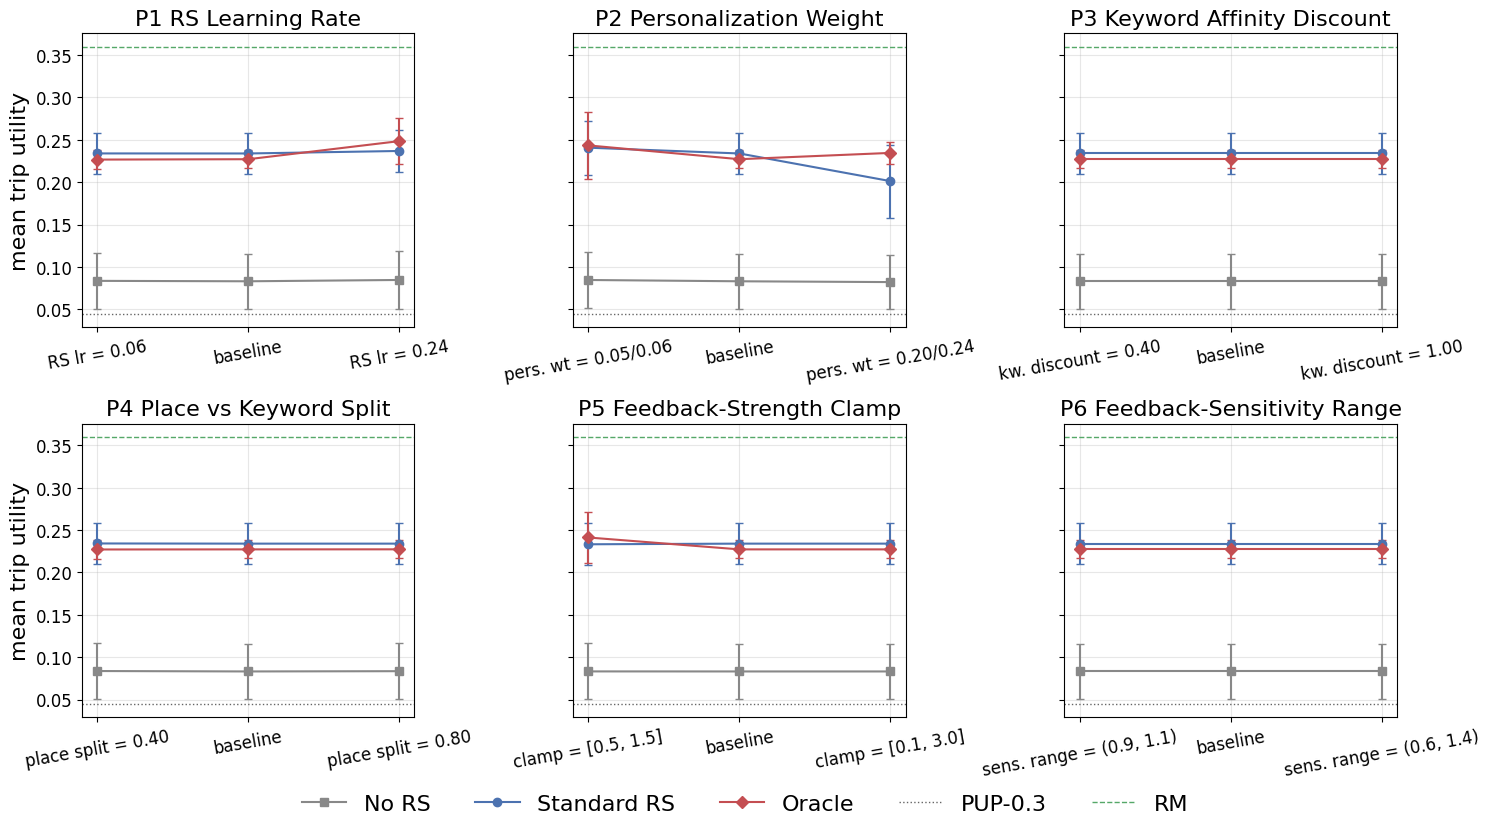

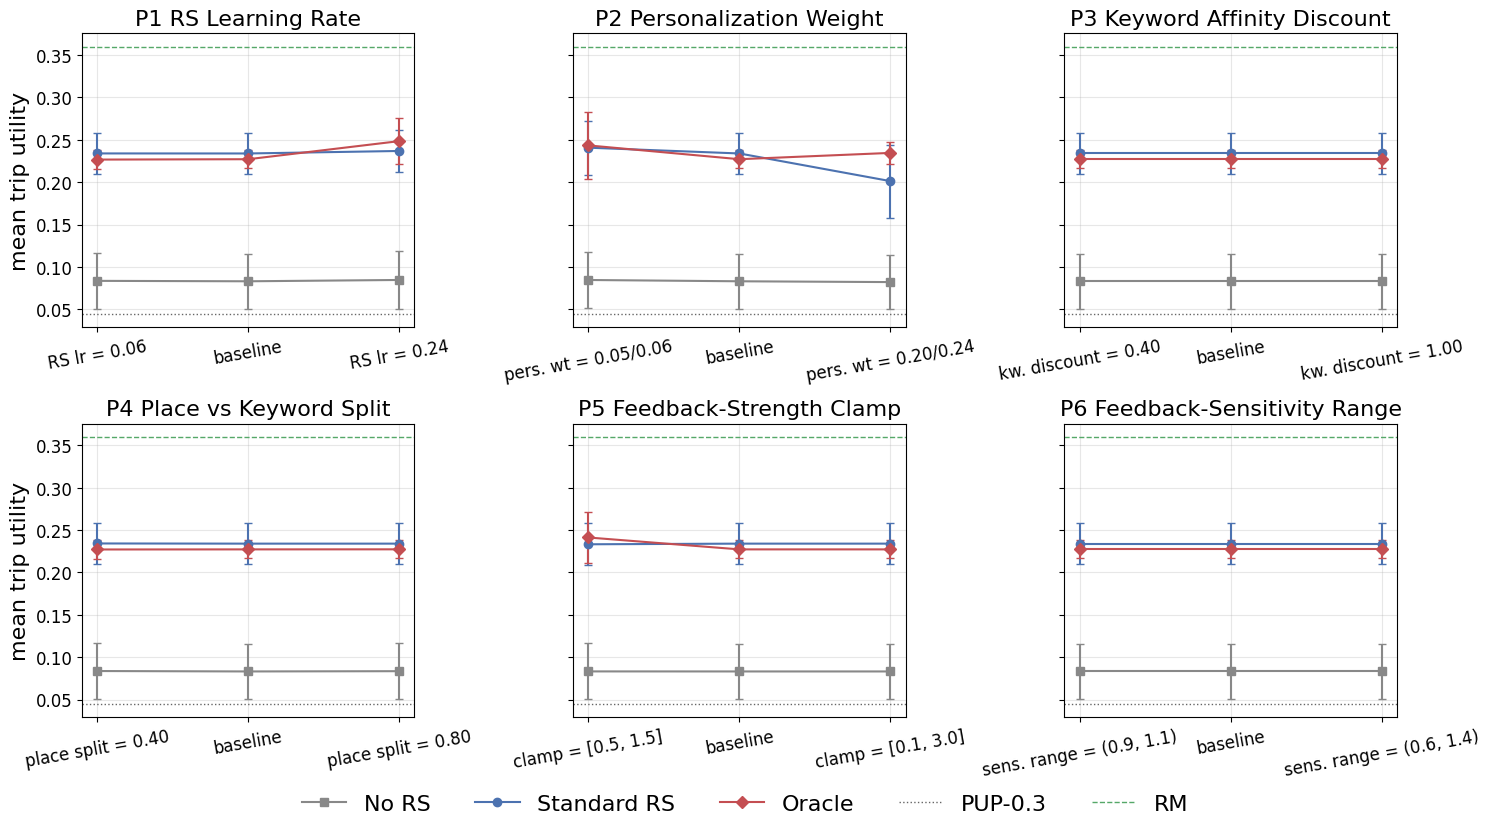

In [43]:
style = {
    "figsize": (15, 8),
    "sharey": True,
    "suptitle": "Task 2: OFAT sensitivity — personalization / feedback-learning knobs",
    "suptitle_fs": 12,
    "suptitle_y": 1.03,
    "panel_title_fs": 16,
    "y_label": "mean trip utility",
    "colors":  {"standard": "#888888", "pup_03": "#4C72B0", "rm": "#C44E52"},
    "markers": {"standard": "s",       "pup_03": "o",       "rm": "D"},
    "capsize": 3,
    "line_width": 1.5,
    "ref_styles": {
        "no_rs":  dict(color="#666",    linestyle=":",  lw=1.0, label="No RS"),
        "oracle": dict(color="#55A868", linestyle="--", lw=1.0, label="Oracle"),
    },
    "xtick_fs": 12,
    "xtick_rot": 10,
    "grid_alpha": 0.3,
    "legend_fs": 16,
    "legend_ncol": 5,
    "legend_y": -0.05,
    "ytick_fs": 12,
}

unique_knobs = []
for cm in t2.CONFIG_META:
    if cm["level"] == 0:
        continue
    if cm["knob"] not in [u["knob"] for u in unique_knobs]:
        unique_knobs.append(cm)
by_ct2 = {(r["config"], r["treatment"]): r for r in t2_rows}

knob_names = ["P1 RS Learning Rate", "P2 Personalization Weight", "P3 Keyword Affinity Discount",
              "P4 Place vs Keyword Split", "P5 Feedback-Strength Clamp", "P6 Feedback-Sensitivity Range"]

fig2, axes2 = plt.subplots(2, 3, figsize=style["figsize"], sharey=style["sharey"])
axes_flat = axes2.flatten()

for i, uk in enumerate(unique_knobs):
    ax = axes_flat[i]
    knob_name = uk["knob"]
    entries = [cm for cm in t2.CONFIG_META if cm["knob"] == knob_name]
    levels = [e for e in entries if e["level"] == -1]
    levels.append(next(cm for cm in t2.CONFIG_META if cm["level"] == 0))
    levels.extend([e for e in entries if e["level"] == 1])

    xs = list(range(len(levels)))
    xlabels = [e["label"].replace("\\,", " ").replace("\\", "") for e in levels]
    for tr in t2.SENSITIVE:
        ys   = [by_ct2[(e["config"], tr)]["mean_U_mean"] for e in levels]
        errs = [by_ct2[(e["config"], tr)]["mean_U_sd"]   for e in levels]
        ax.errorbar(xs, ys, yerr=errs,
                    marker=style["markers"][tr],
                    color=style["colors"][tr],
                    linewidth=style["line_width"],
                    capsize=style["capsize"],
                    label=t2.TREATMENT_LABELS[tr].replace("\\", ""))
    for tr_ref, kw in style["ref_styles"].items():
        ax.axhline(t2_invariant[tr_ref]["mean_U_mean"], **kw)

    ax.set_title(knob_names[i], fontsize=style["panel_title_fs"])
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, fontsize=style["xtick_fs"], rotation=style["xtick_rot"])
    ax.tick_params(axis='y', labelsize=style["ytick_fs"])
    if i % 3 == 0:
        ax.set_ylabel(style["y_label"], fontsize=style["panel_title_fs"])
    ax.grid(True, alpha=style["grid_alpha"])

handles = [
    mlines.Line2D([], [], color=style["colors"][tr], marker=style["markers"][tr],
                  label=t2.TREATMENT_LABELS[tr].replace("\\", ""))
    for tr in t2.SENSITIVE
]
for tr_ref, kw in style["ref_styles"].items():
    handles.append(mlines.Line2D([], [], **kw))
fig2.legend(handles, labels, loc="lower center", ncol=style["legend_ncol"],
            frameon=False, bbox_to_anchor=(0.5, style["legend_y"]),
            fontsize=style["legend_fs"])
#fig2.suptitle(style["suptitle"], y=style["suptitle_y"], fontsize=style["suptitle_fs"])
fig2.tight_layout()
fig2


## Set 3 — RS-stack / catalog knobs

2×3 panel. Same axis grammar as Set 2. Oracle is analytically
invariant to knobs S1, S2, S3, S5, S6 (it scores candidates against
agent preferences and ignores prom/rel/proximity weights, review
volume, and popularity multipliers) but reads `place.rating / 5.0`, so
the baseline Oracle reference is slightly off under S4. The paired
metrics (`pct_harmed`, `orc`) are unaffected because they reference
baseline No-RS only.


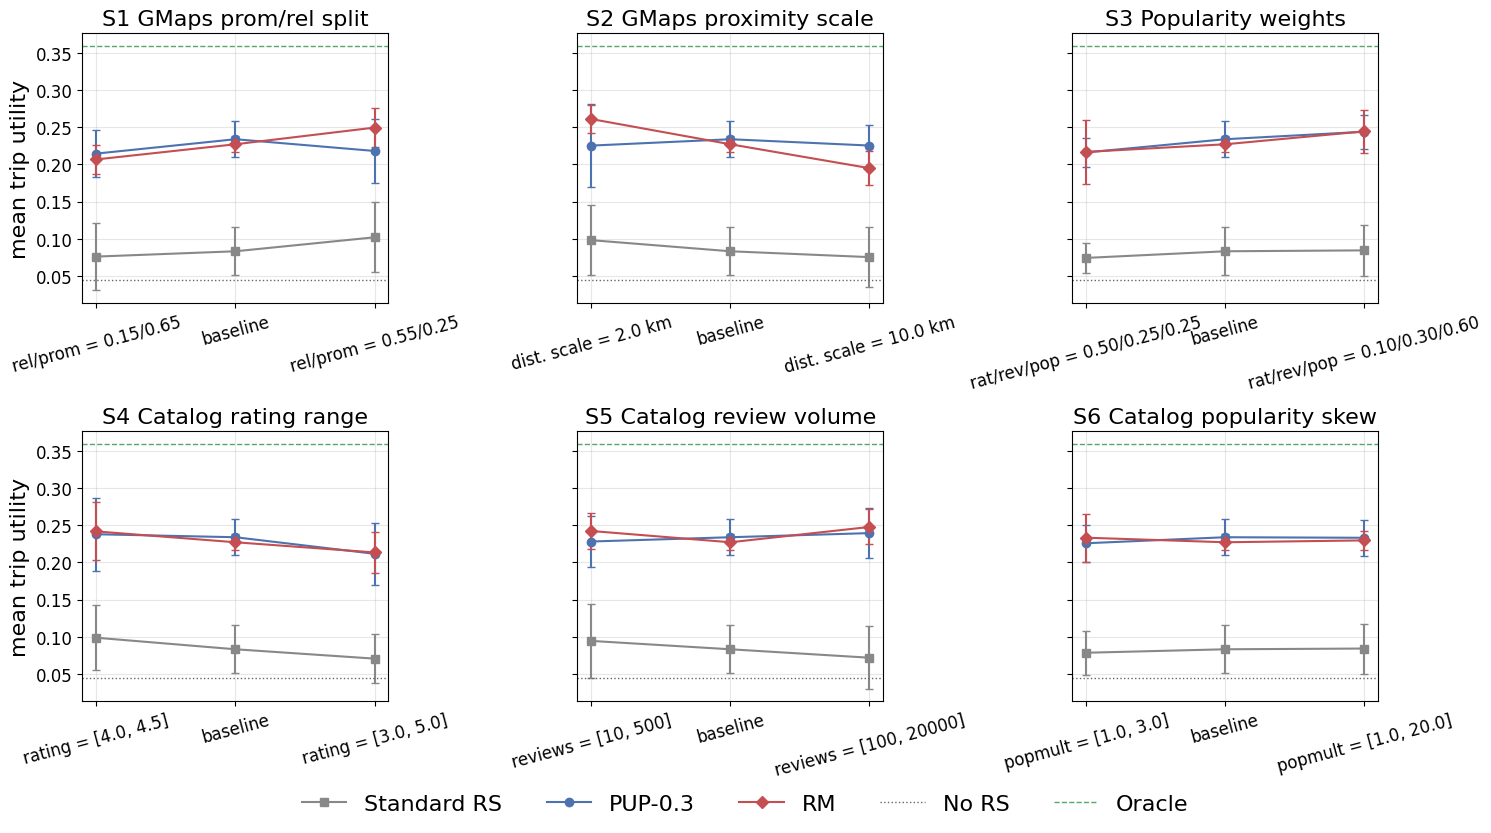

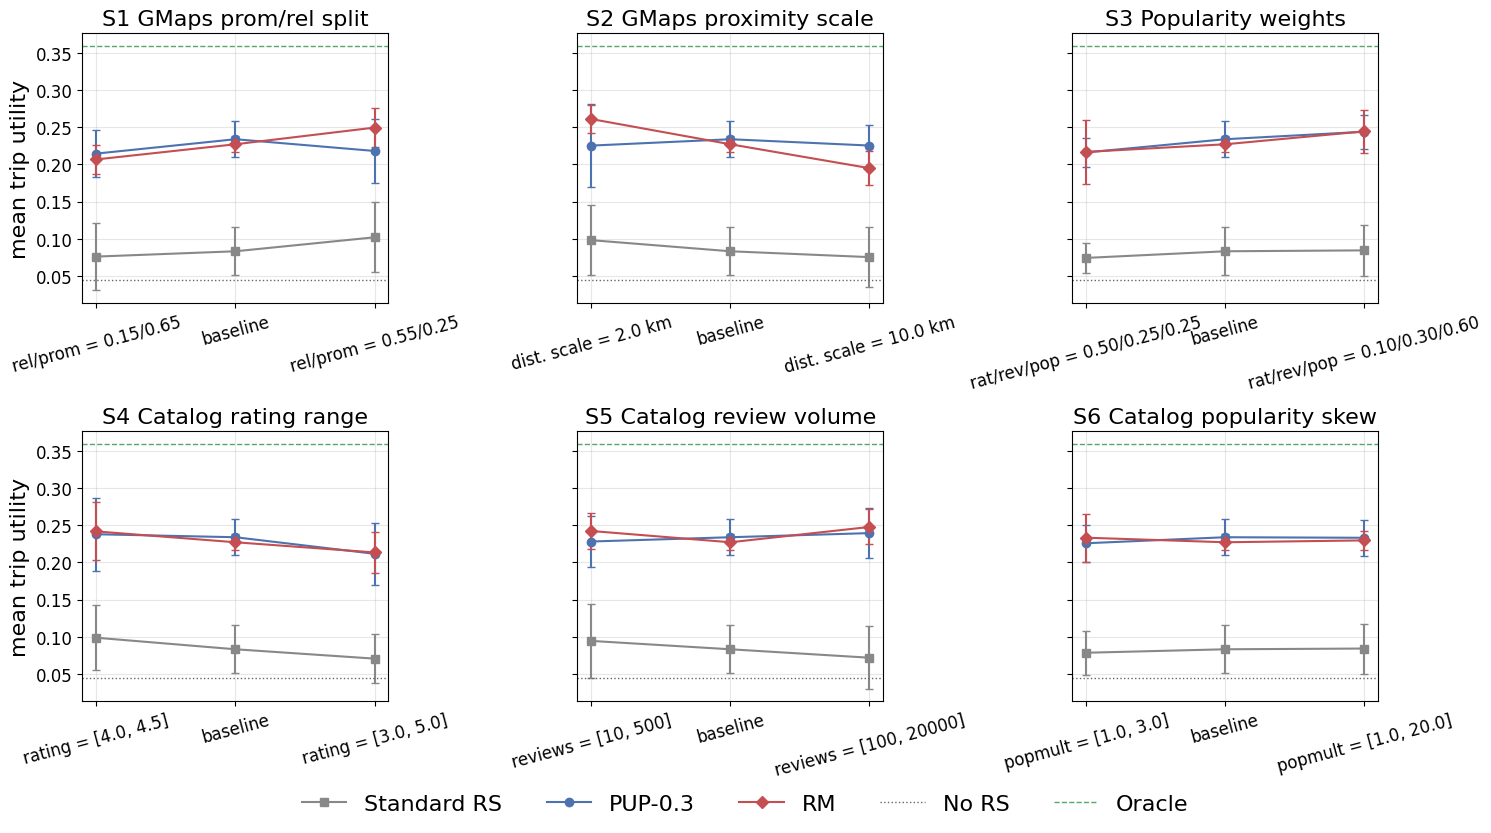

In [44]:
style = {
    "figsize": (15, 8),
    "sharey": True,
    "suptitle": "Task 3: OFAT sensitivity — base-RS-stack / catalog knobs",
    "suptitle_fs": 12,
    "suptitle_y": 1.03,
    "panel_title_fs": 16,
    "y_label": "mean trip utility",
    "colors":  {"standard": "#888888", "pup_03": "#4C72B0", "rm": "#C44E52"},
    "markers": {"standard": "s",       "pup_03": "o",       "rm": "D"},
    "capsize": 3,
    "line_width": 1.5,
    "ref_styles": {
        "no_rs":  dict(color="#666",    linestyle=":",  lw=1.0, label="No RS"),
        "oracle": dict(color="#55A868", linestyle="--", lw=1.0, label="Oracle"),
    },
    "xtick_fs": 12,
    "xtick_rot": 15,
    "grid_alpha": 0.3,
    "legend_ncol": 5,
    "legend_y": -0.05,
    "legend_fs": 16,
    "ytick_fs": 12,
}

unique_knobs = []
for cm in t3.CONFIG_META:
    if cm["level"] == 0:
        continue
    if cm["knob"] not in [u["knob"] for u in unique_knobs]:
        unique_knobs.append(cm)
by_ct3 = {(r["config"], r["treatment"]): r for r in t3_rows}

fig3, axes3 = plt.subplots(2, 3, figsize=style["figsize"], sharey=style["sharey"])
axes_flat = axes3.flatten()

for i, uk in enumerate(unique_knobs):
    ax = axes_flat[i]
    knob_name = uk["knob"]
    entries = [cm for cm in t3.CONFIG_META if cm["knob"] == knob_name]
    levels = [e for e in entries if e["level"] == -1]
    levels.append(next(cm for cm in t3.CONFIG_META if cm["level"] == 0))
    levels.extend([e for e in entries if e["level"] == 1])

    xs = list(range(len(levels)))
    xlabels = [e["label"].replace("\\,", " ").replace("\\", "") for e in levels]
    for tr in t3.SENSITIVE:
        ys   = [by_ct3[(e["config"], tr)]["mean_U_mean"] for e in levels]
        errs = [by_ct3[(e["config"], tr)]["mean_U_sd"]   for e in levels]
        ax.errorbar(xs, ys, yerr=errs,
                    marker=style["markers"][tr],
                    color=style["colors"][tr],
                    linewidth=style["line_width"],
                    capsize=style["capsize"],
                    label=t3.TREATMENT_LABELS[tr].replace("\\", ""))
    for tr_ref, kw in style["ref_styles"].items():
        ax.axhline(t3_invariant[tr_ref]["mean_U_mean"], **kw)

    ax.set_title(knob_name, fontsize=style["panel_title_fs"])
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, fontsize=style["xtick_fs"], rotation=style["xtick_rot"])
    ax.tick_params(axis='y', labelsize=style["ytick_fs"])
    if i % 3 == 0:
        ax.set_ylabel(style["y_label"], fontsize=style["panel_title_fs"])
    ax.grid(True, alpha=style["grid_alpha"])

handles = [
    mlines.Line2D([], [], color=style["colors"][tr], marker=style["markers"][tr],
                  label=t3.TREATMENT_LABELS[tr])
    for tr in t3.SENSITIVE
]

for tr_ref, kw in style["ref_styles"].items():
    handles.append(mlines.Line2D([], [], **kw))
fig3.legend(handles=handles, loc="lower center", ncol=style["legend_ncol"],
            bbox_to_anchor=(0.5, style["legend_y"]), frameon=False, fontsize=style["legend_fs"])
#fig3.suptitle(style["suptitle"], y=style["suptitle_y"], fontsize=style["suptitle_fs"])
fig3.tight_layout()
fig3


## Save (optional)

Set `save = True` and pick a `suffix` to write the edited figures to
`figs/robustness/`. Leave `suffix = ""` to overwrite the originals.


In [ ]:
save = False
suffix = "_edited"   # set to "" to overwrite the originals from the analyze scripts

if save:
    for fig, name in [(fig1, "task1"), (fig2, "task2"), (fig3, "task3")]:
        fig.savefig(FIG_DIR / f"{name}_panels{suffix}.png", dpi=150, bbox_inches="tight")
        fig.savefig(FIG_DIR / f"{name}_panels{suffix}.pdf",            bbox_inches="tight")
    print(f"Saved 6 files to {FIG_DIR} with suffix '{suffix}'.")
else:
    print("Saving disabled. Set `save = True` to write.")


Saving disabled. Set `save = True` to write.
